# K-Nearest Neighbor

### 다음처럼 카테고리가 레이블링 되어 있는 데이터가 존재합니다.

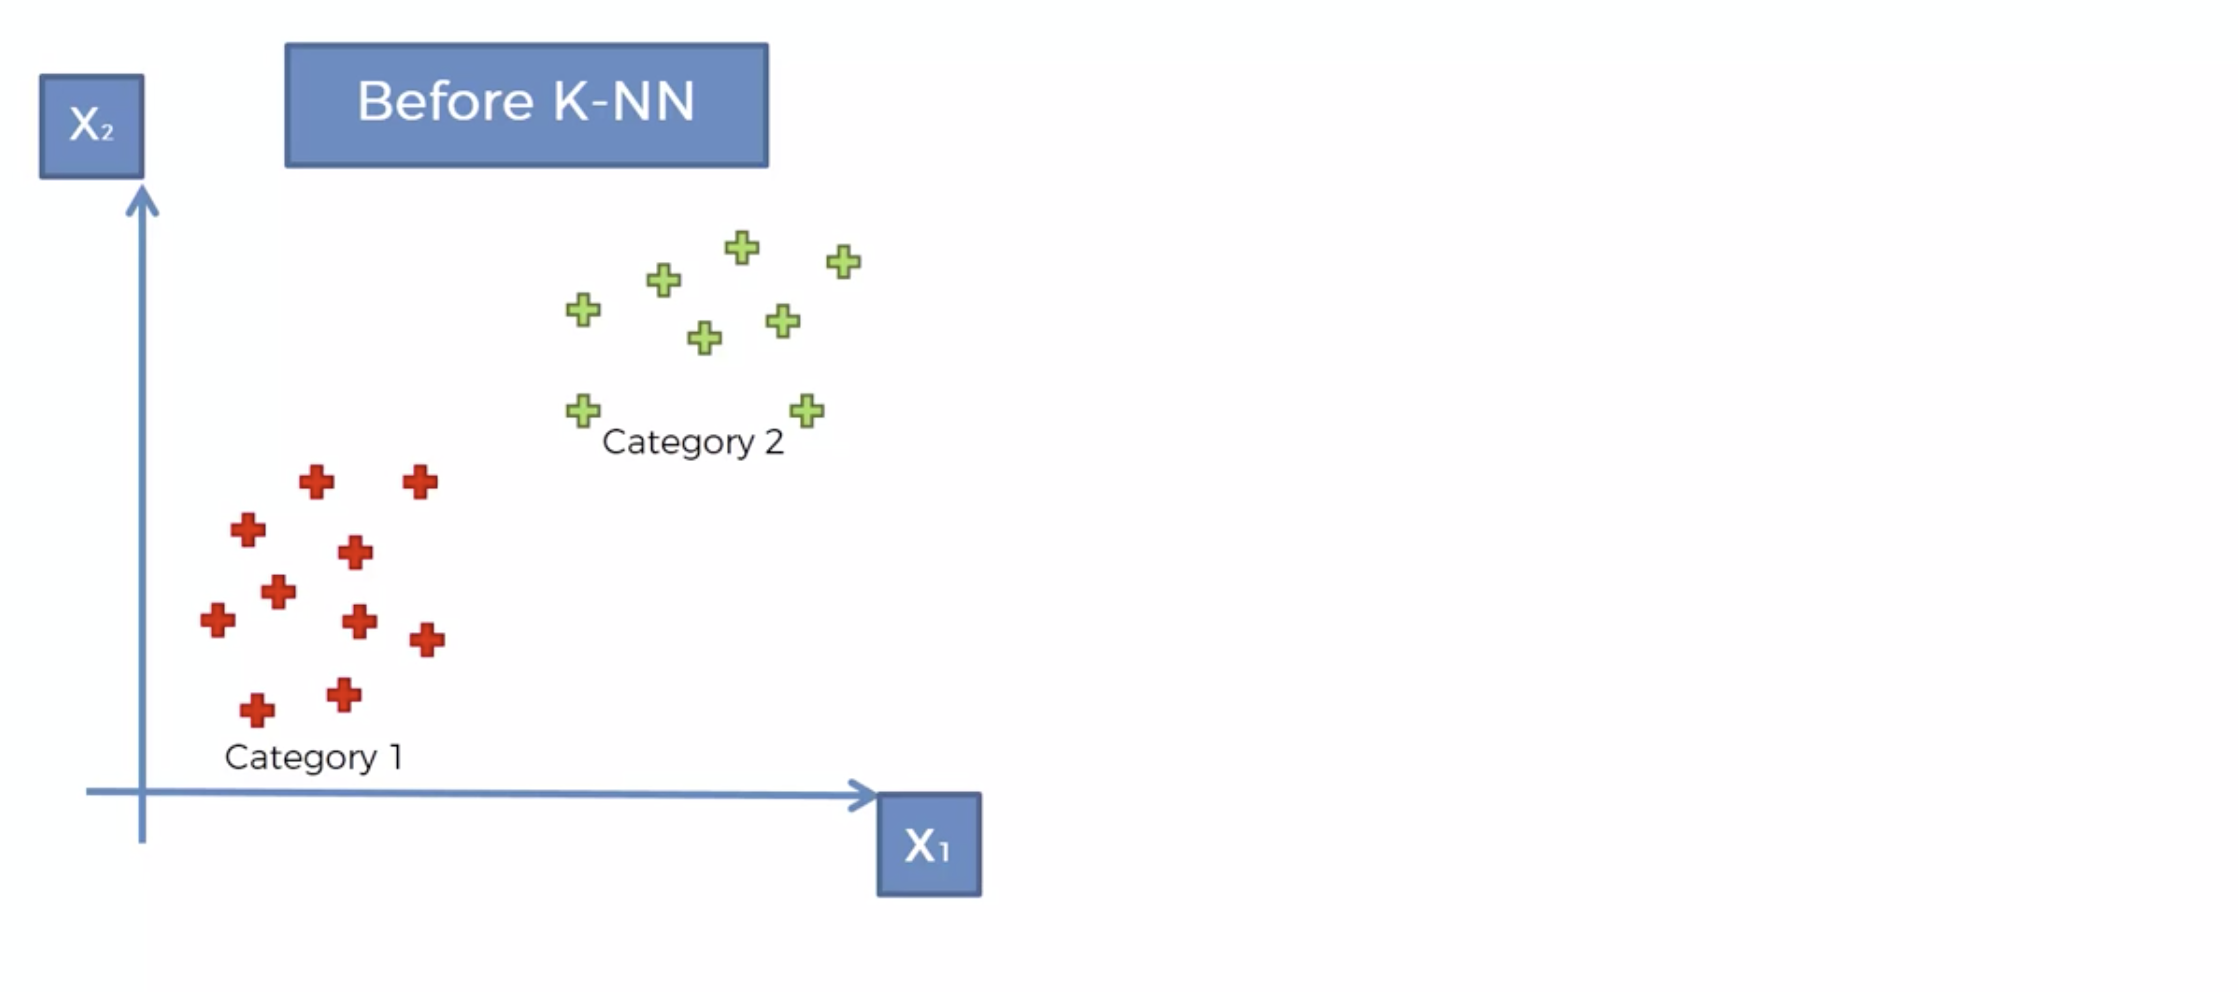

### 새로운 데이터가 생겼을때, 이를 어디로 분류해야 할까요?

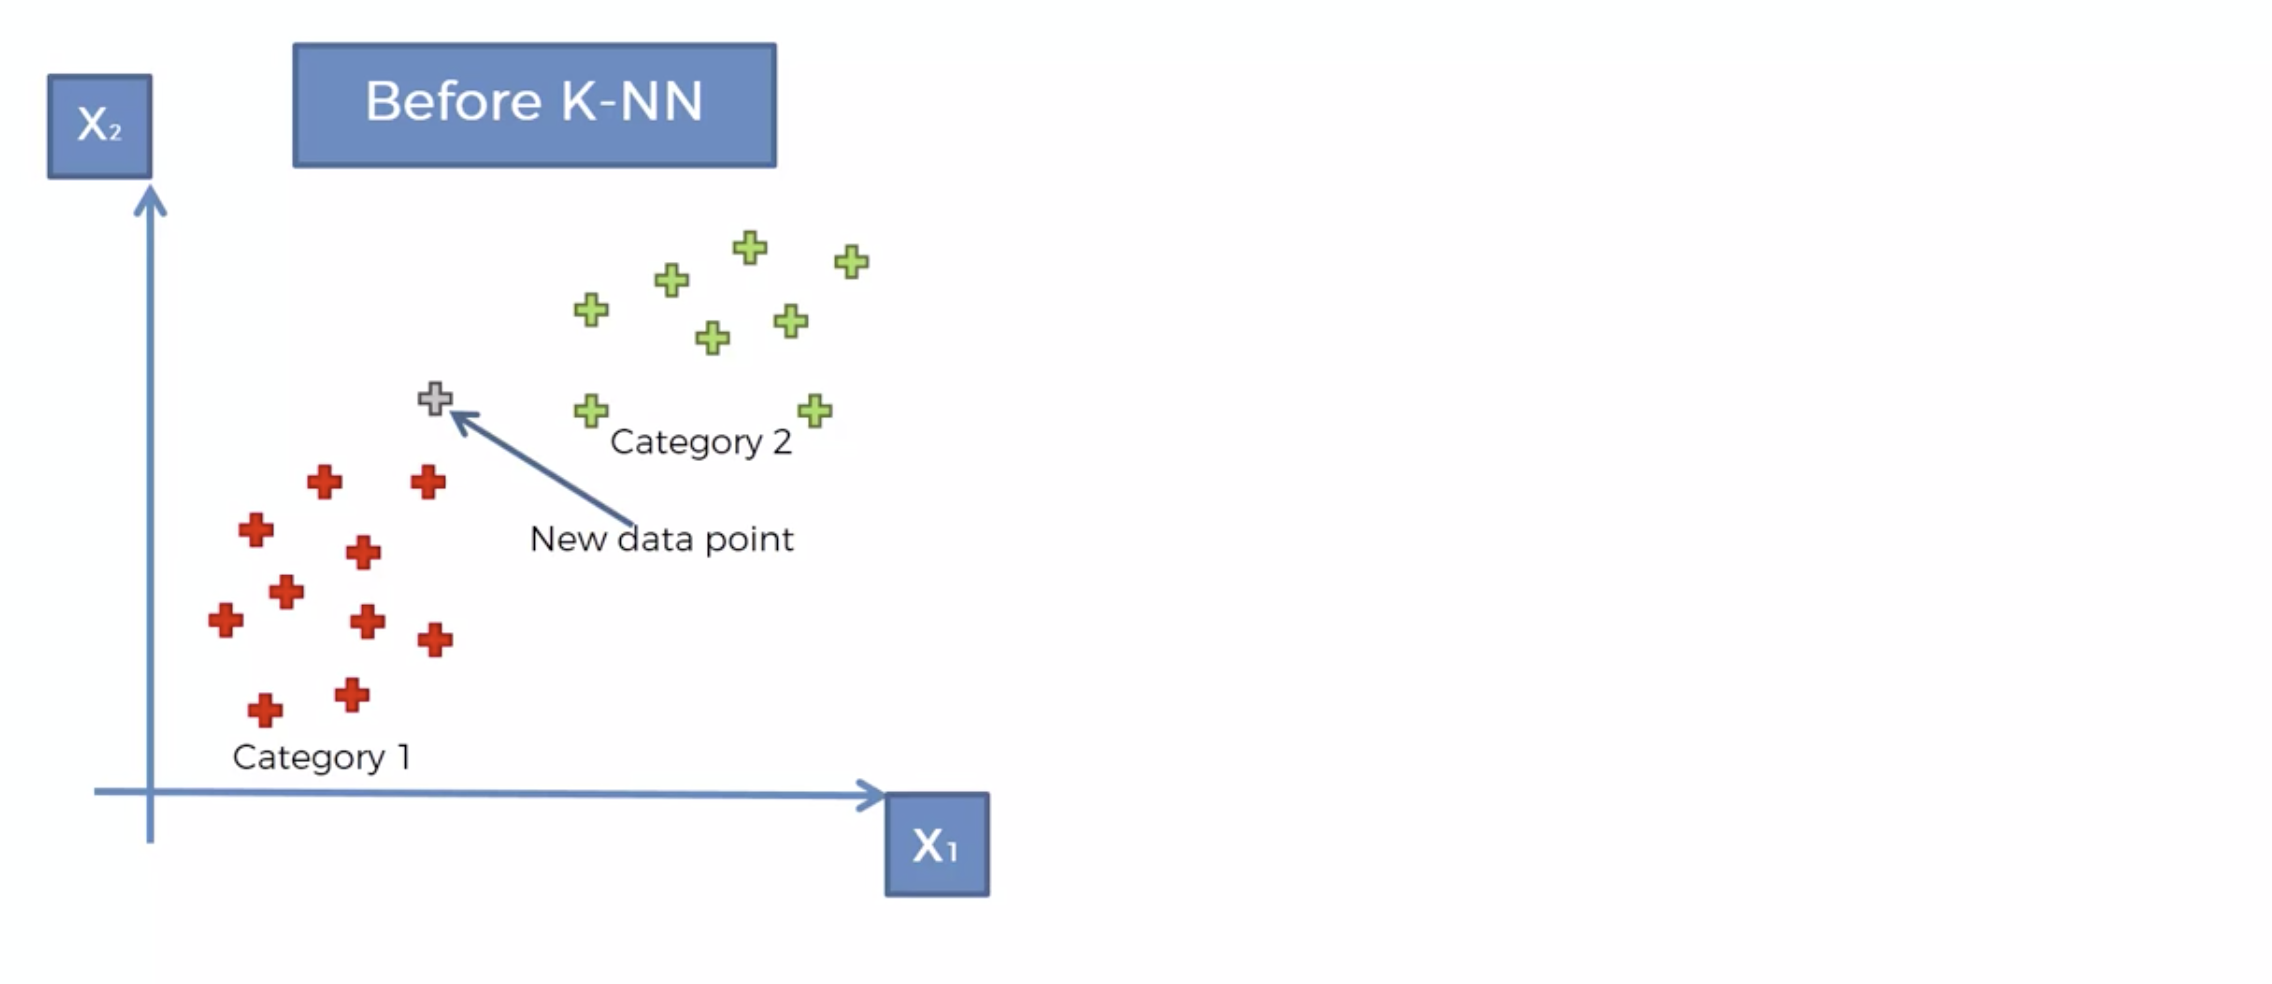

### 왜 빨간색으로 분류를 했을까요.

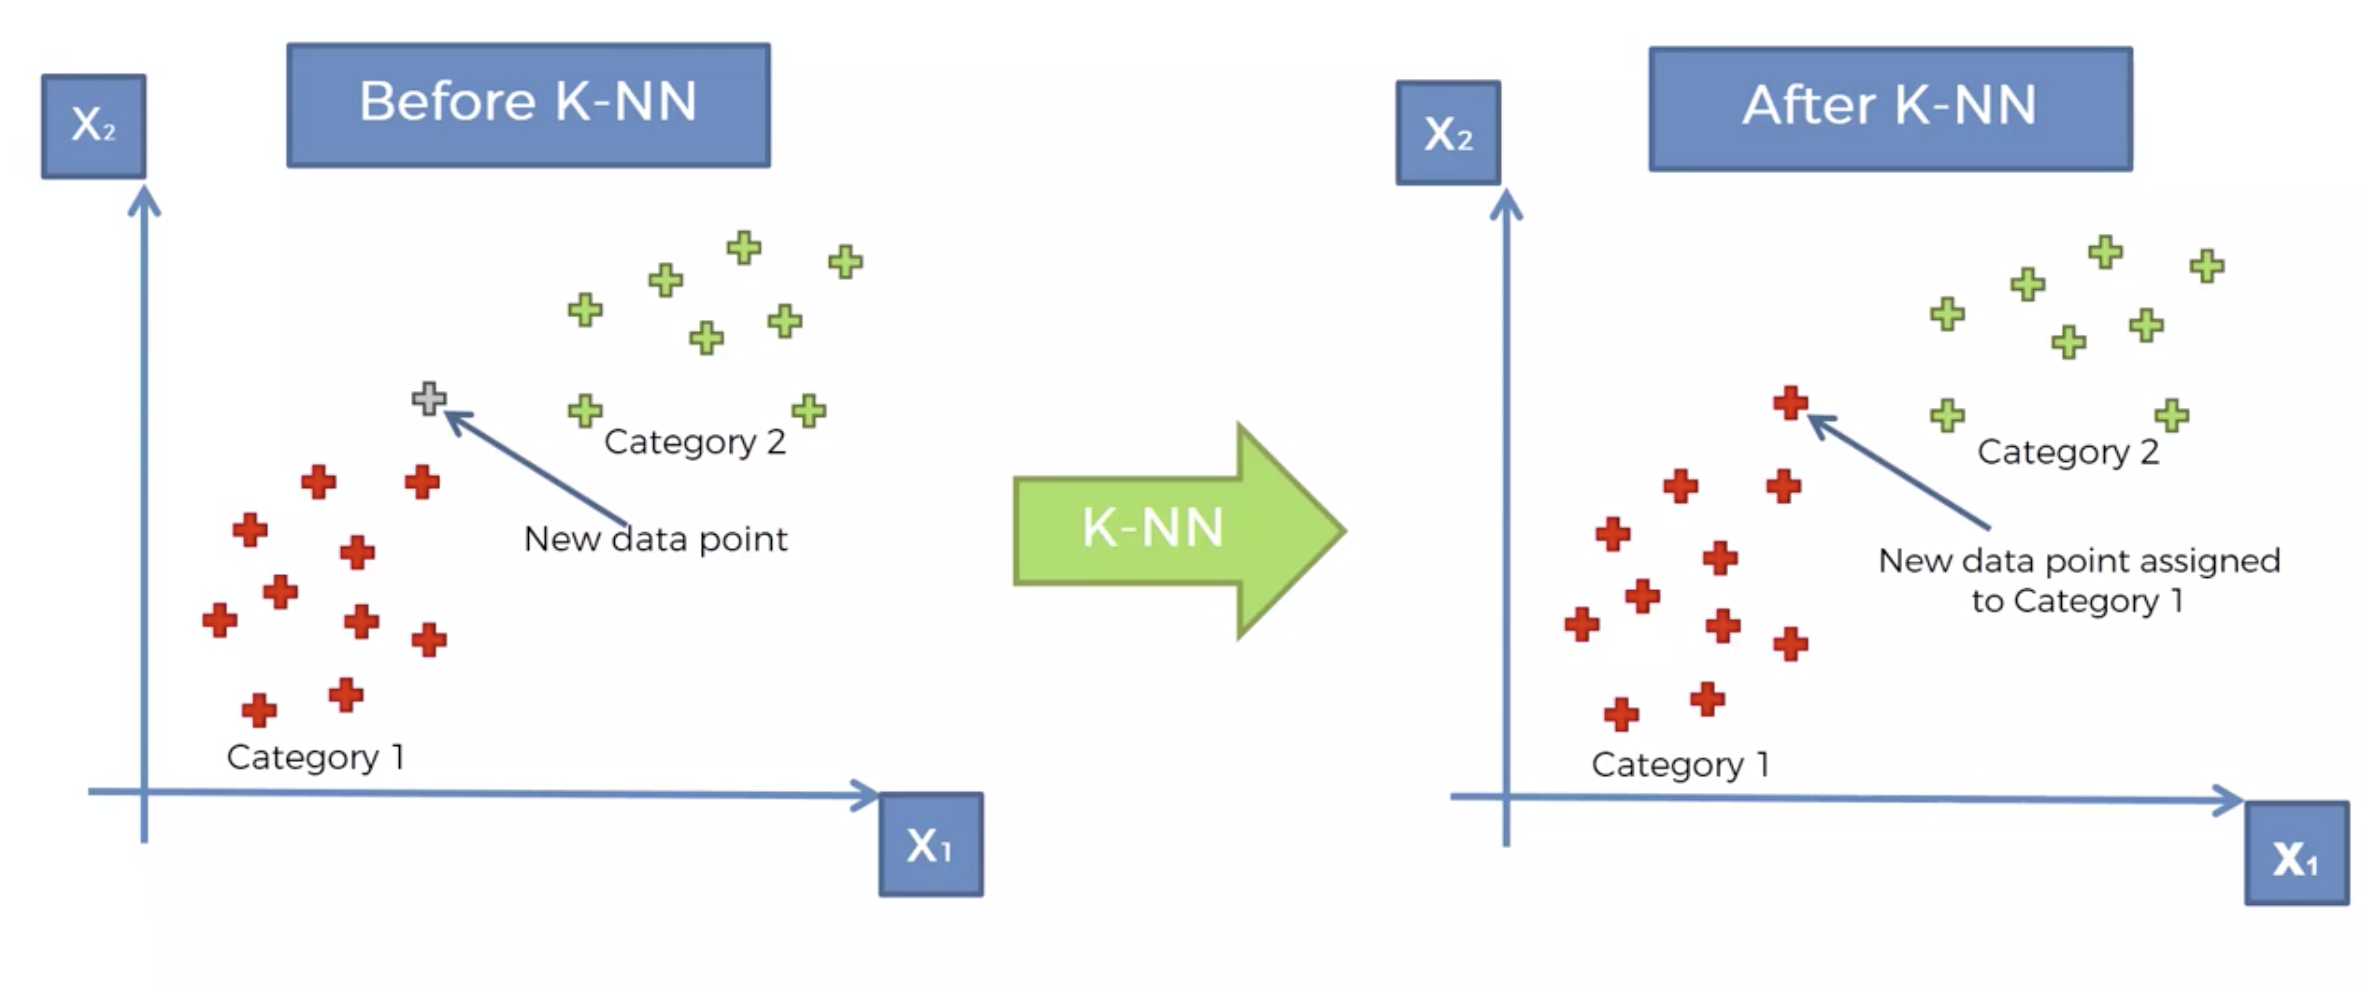

# KNN 알고리즘

### 내 주위에 몇개의 이웃을 확인해 볼것인가를 결정한다. => K

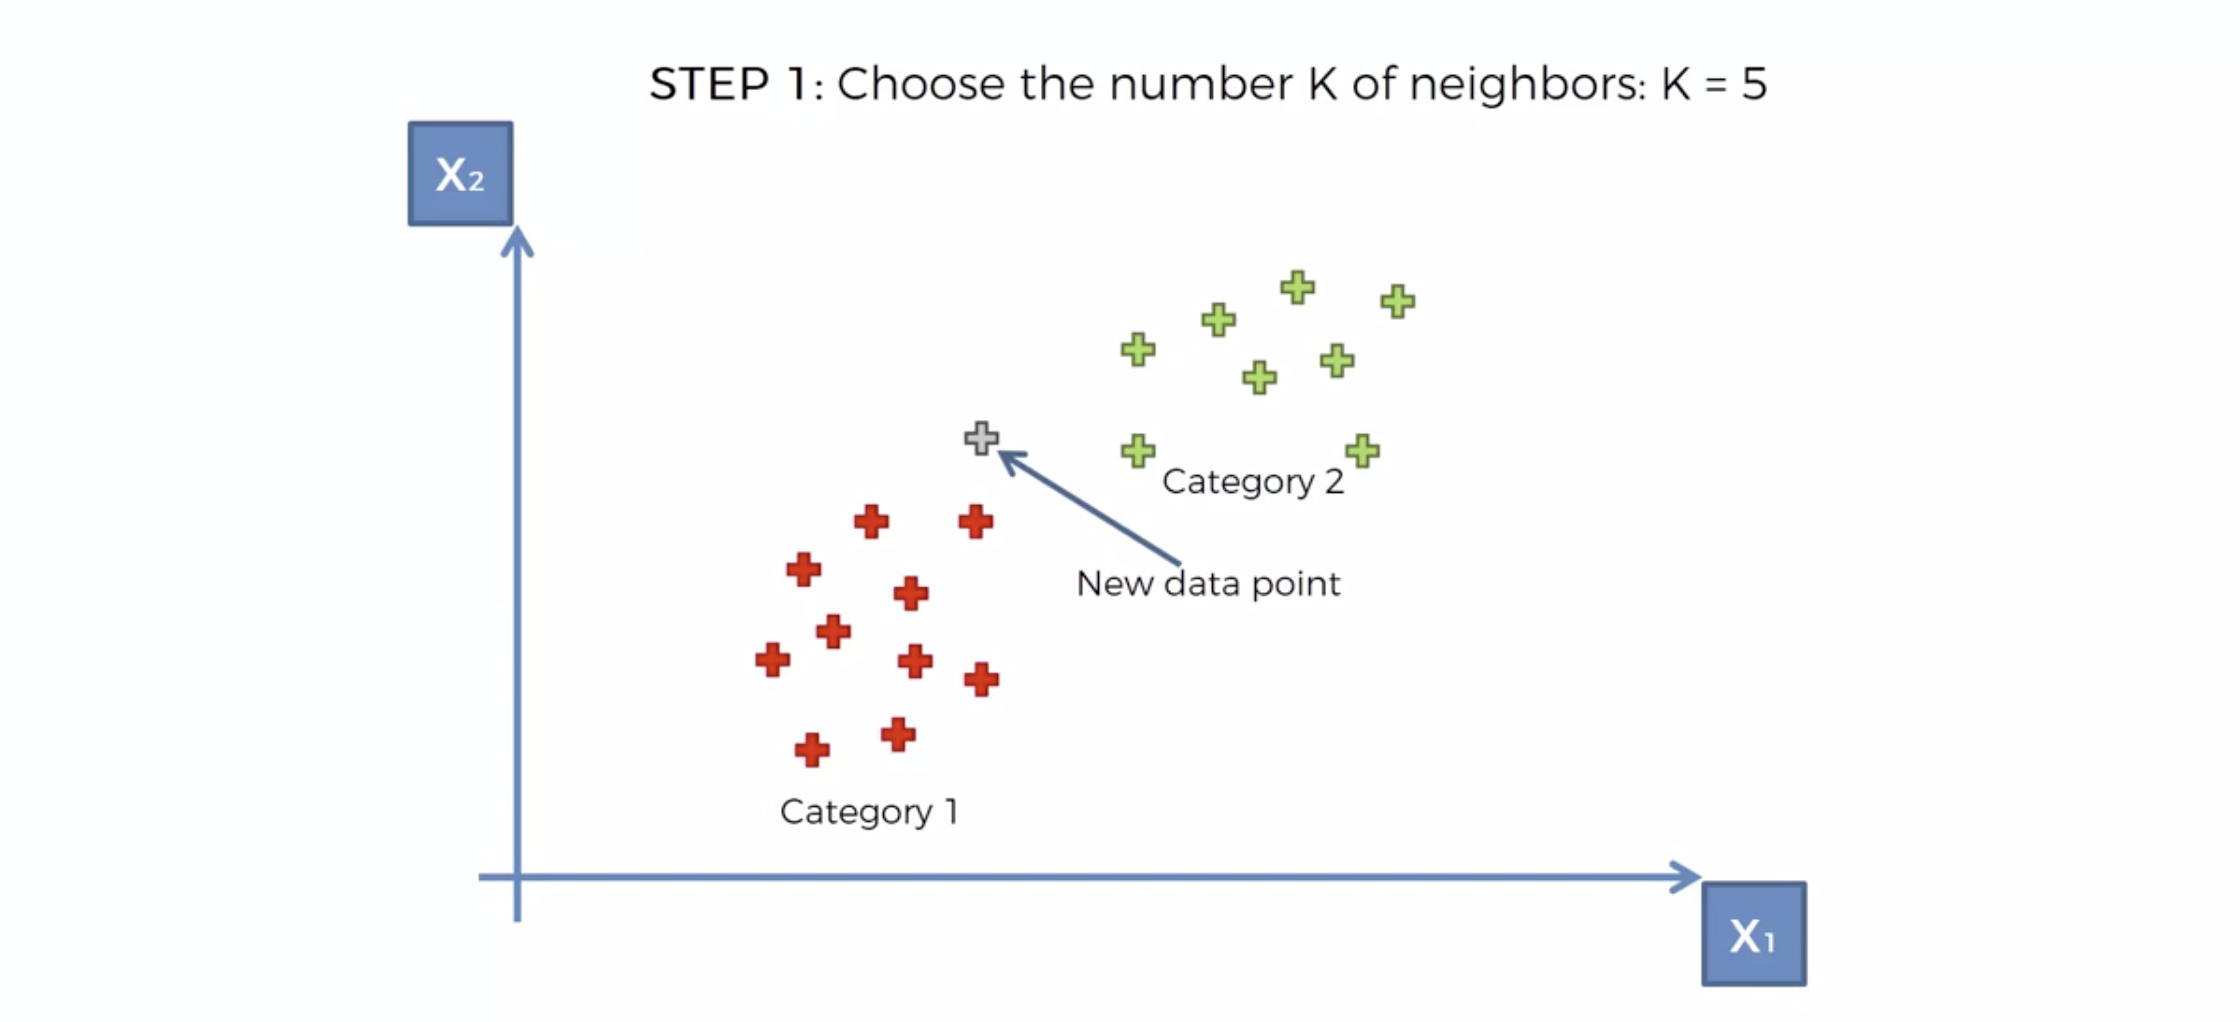

### 새로운 데이터가 발생 시, Euclidean distance 에 의해서, 가장 가까운 K 개의 이웃을 택한다.

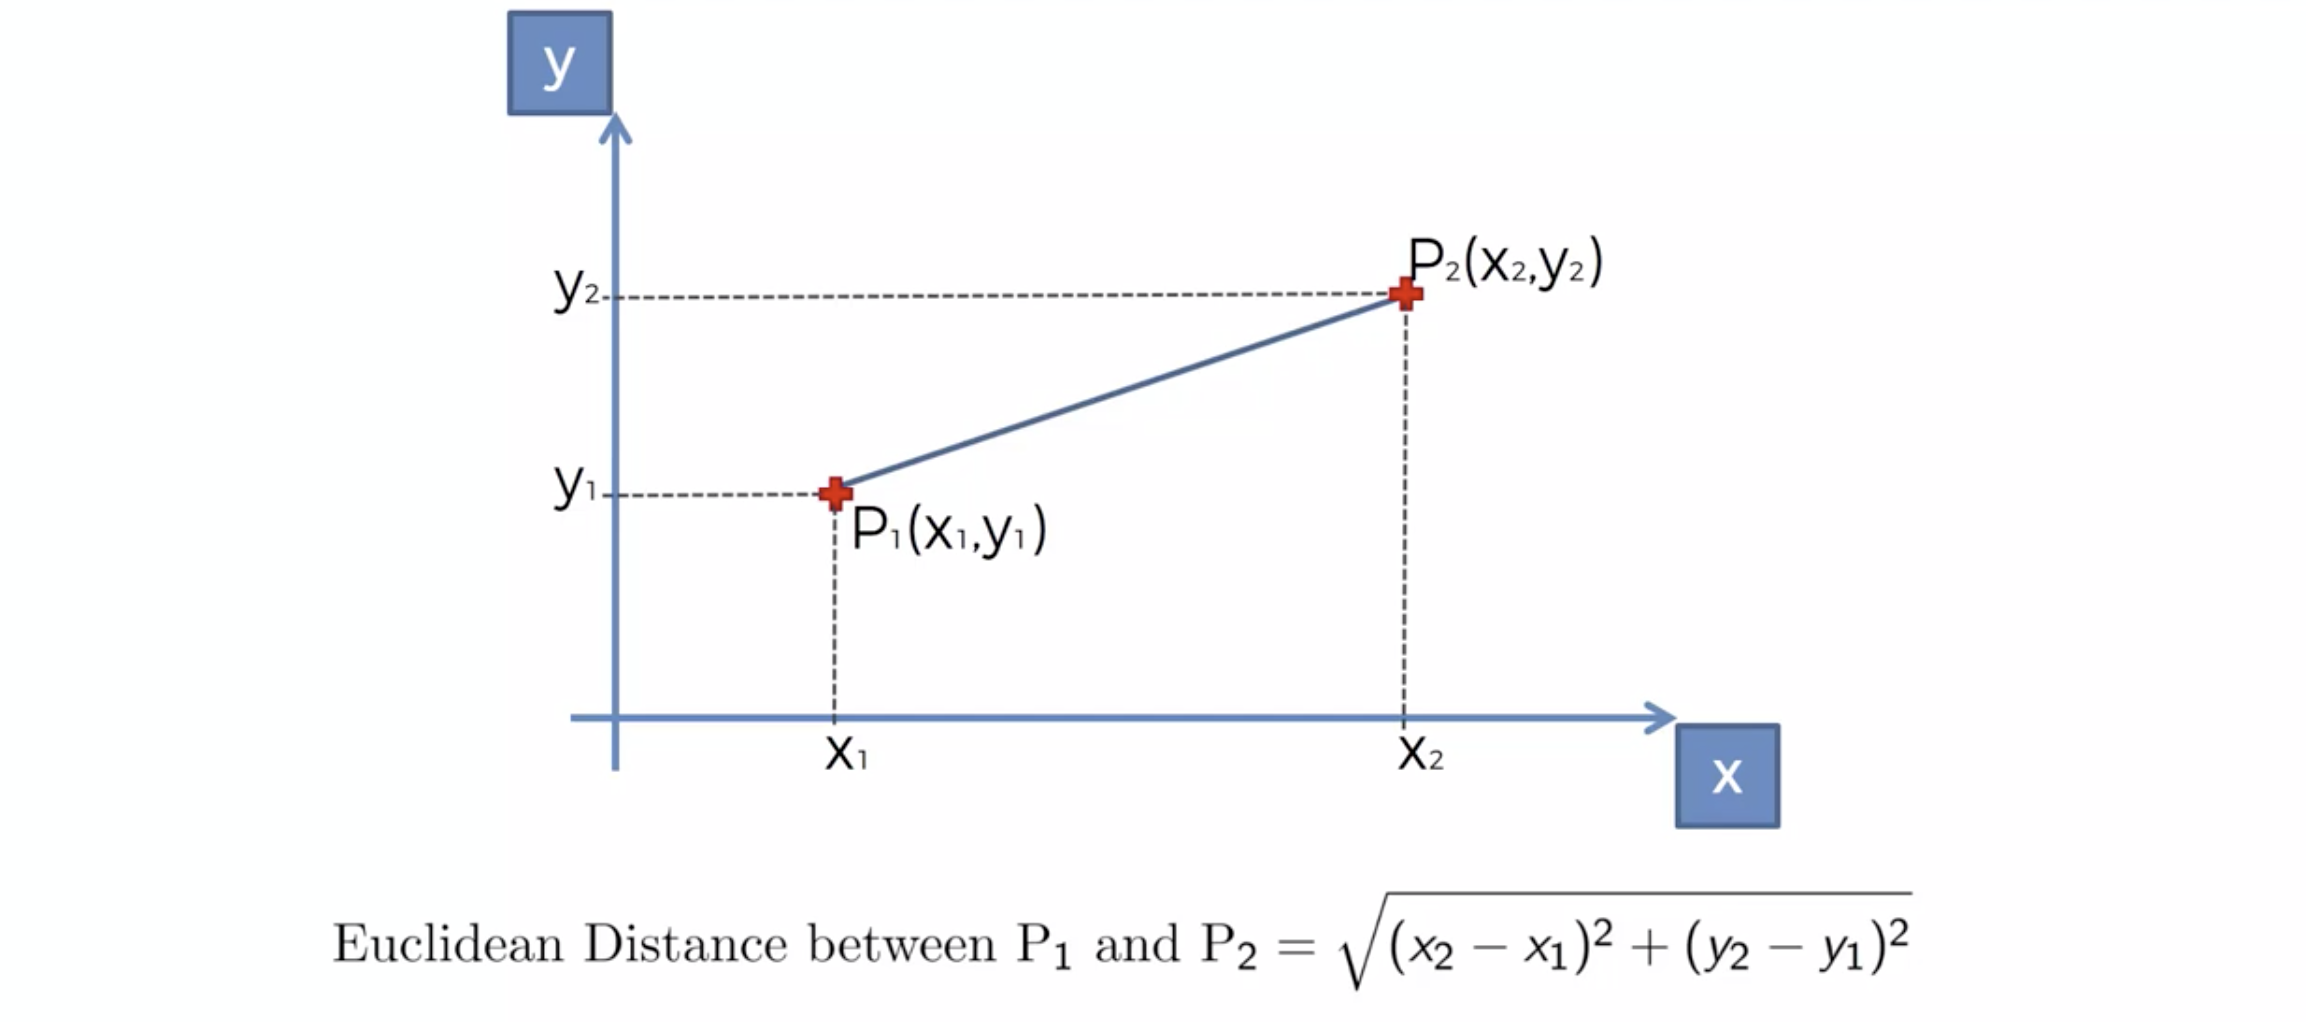

### K 개의 이웃의 카테고리를 확인한다.

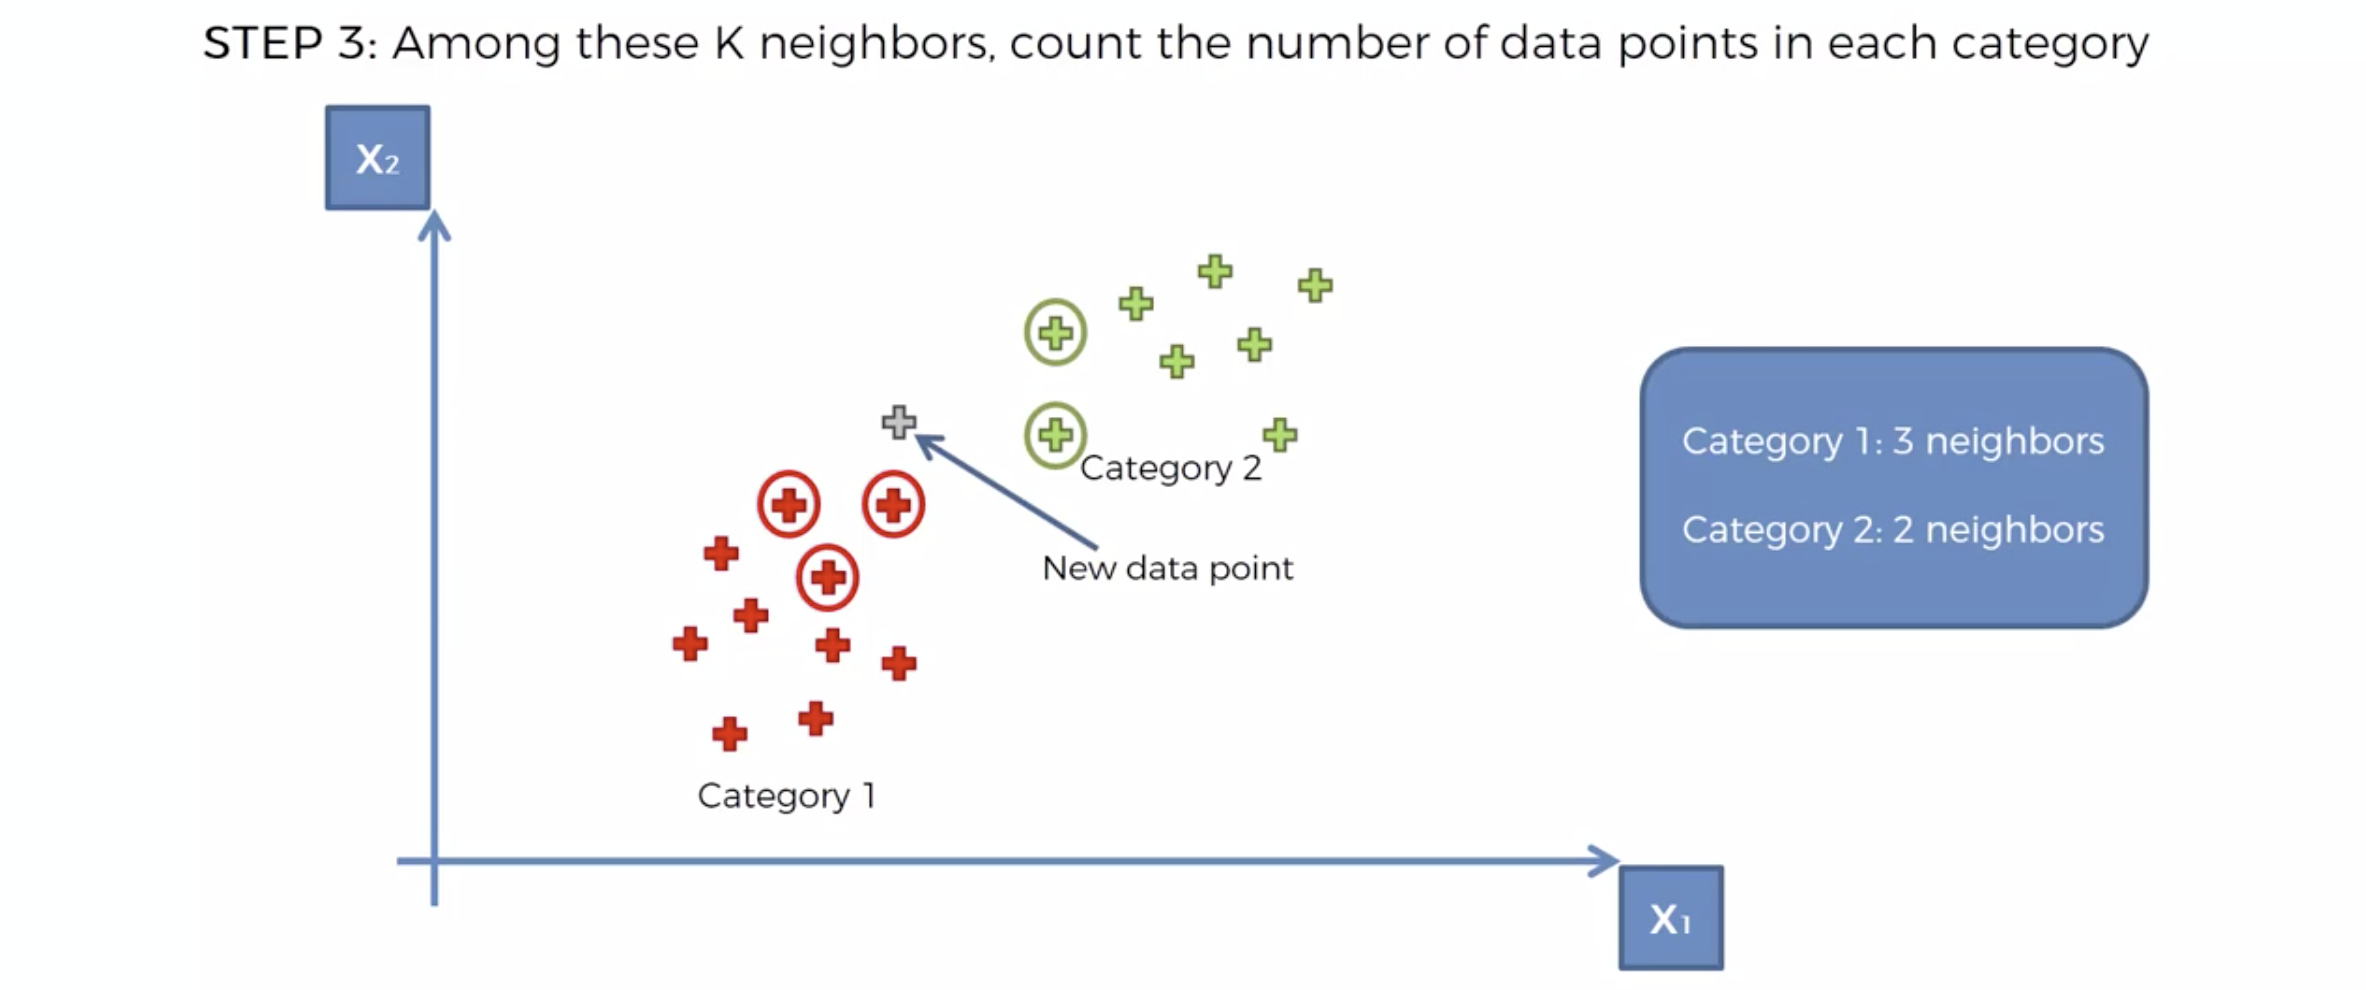

### 카테고리의 숫자가 많은 쪽으로, 새로운 데이터의 카테고리를 정해버린다.

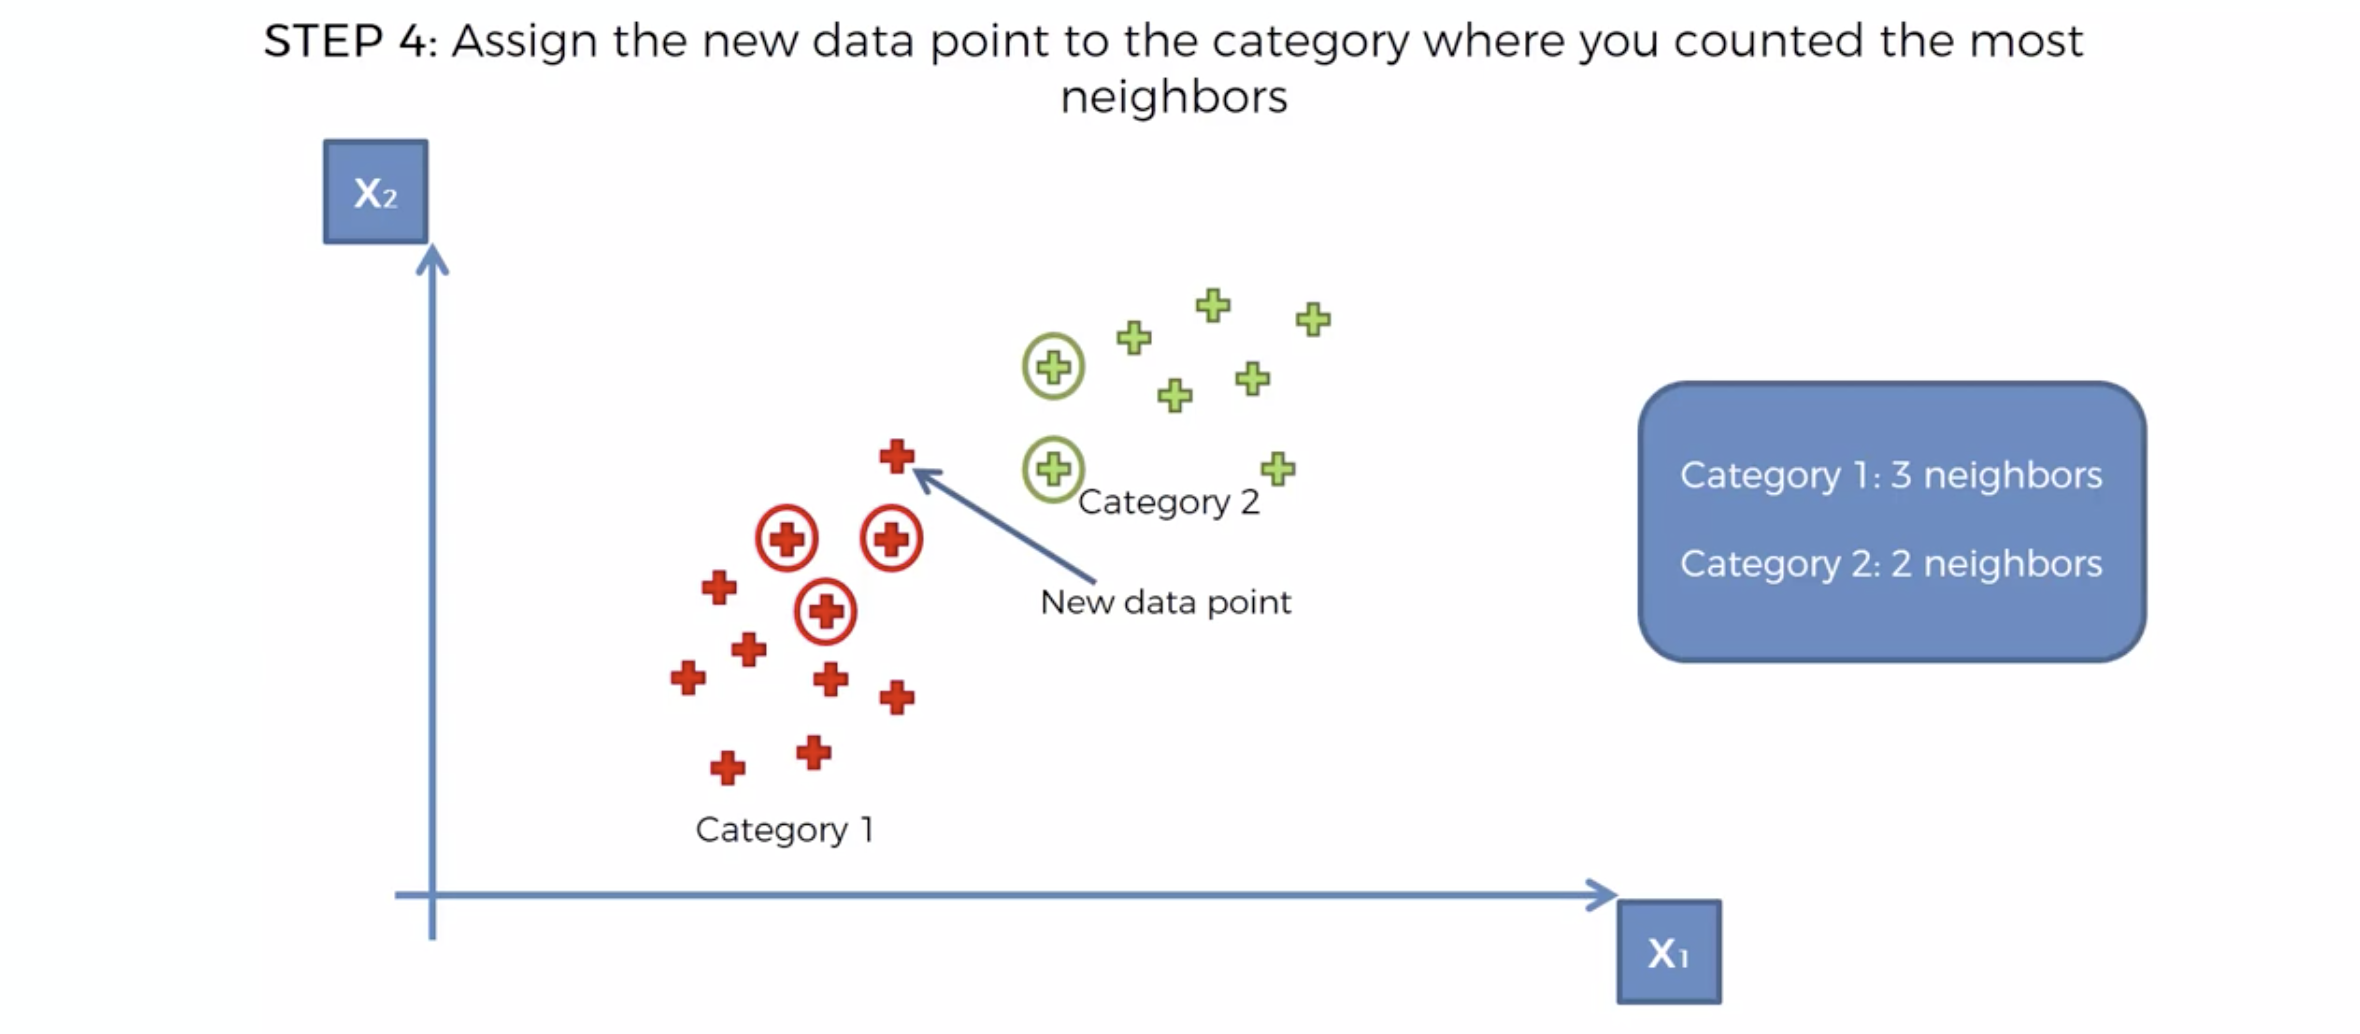

In [2]:
import pandas as pd
import numpy as np

In [4]:
data_path = 'datas_ml/Social_Network_Ads.csv'
df = pd.read_csv(data_path)
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
X = df[['Gender', 'Age', 'EstimatedSalary']]

In [6]:
y = df['Purchased']

In [7]:
def get_gender(gender):
    if gender == "Male":
        return 0
    else :
        return 1

In [8]:
# X['Gender'].apply(get_gender)
X['Gender'] = X['Gender'].apply(get_gender)

C:\Users\magpi\AppData\Local\Temp\ipykernel_28080\1198891261.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Gender'] = X['Gender'].apply(get_gender)


In [12]:
from sklearn.preprocessing import StandardScaler
X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)
X_scaled

array([[-1.02020406, -1.78179743, -1.49004624],
       [-1.02020406, -0.25358736, -1.46068138],
       [ 0.98019606, -1.11320552, -0.78528968],
       ...,
       [ 0.98019606,  1.17910958, -1.46068138],
       [-1.02020406, -0.15807423, -1.07893824],
       [ 0.98019606,  1.08359645, -0.99084367]], shape=(400, 3))

# train, test 데이터 분할

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=7)

In [14]:
X_train.shape, y_train.shape

((300, 3), (300,))

In [15]:
X_test.shape, y_test.shape

((100, 3), (100,))

# 모델 학습

In [16]:
from sklearn.neighbors import KNeighborsClassifier

In [17]:
classifier = KNeighborsClassifier(n_neighbors=7)

In [18]:
classifier.fit(X_train, y_train)

,n_neighbors,7
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [19]:
classifier.n_neighbors

7

In [20]:
y_pred = classifier.predict(X_test)

In [21]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [22]:
confusion_matrix(y_test, y_pred)

array([[64,  4],
       [ 5, 27]])

In [23]:
from sklearn.metrics import classification_report, accuracy_score

# y_test: 실제 라벨, y_pred: 모델 예측 라벨
print("정확도:", accuracy_score(y_test, y_pred))
print("\n[정밀도, 재현율, F1-score 요약 보고서]")
print(classification_report(y_test, y_pred))

정확도: 0.91

[정밀도, 재현율, F1-score 요약 보고서]
              precision    recall  f1-score   support

           0       0.93      0.94      0.93        68
           1       0.87      0.84      0.86        32

    accuracy                           0.91       100
   macro avg       0.90      0.89      0.90       100
weighted avg       0.91      0.91      0.91       100



- KNN k -> 5일 때 0.93
- KNN k -> 7일 때 0.91
- 로지스틱 : 0.86

=> 인공지능은 실험을 많이 해서 좋은 성능을 내는 모델을 찾는 것임
=> 영향을 주는 것
- 데이터, 모델, 하이퍼 파라미터

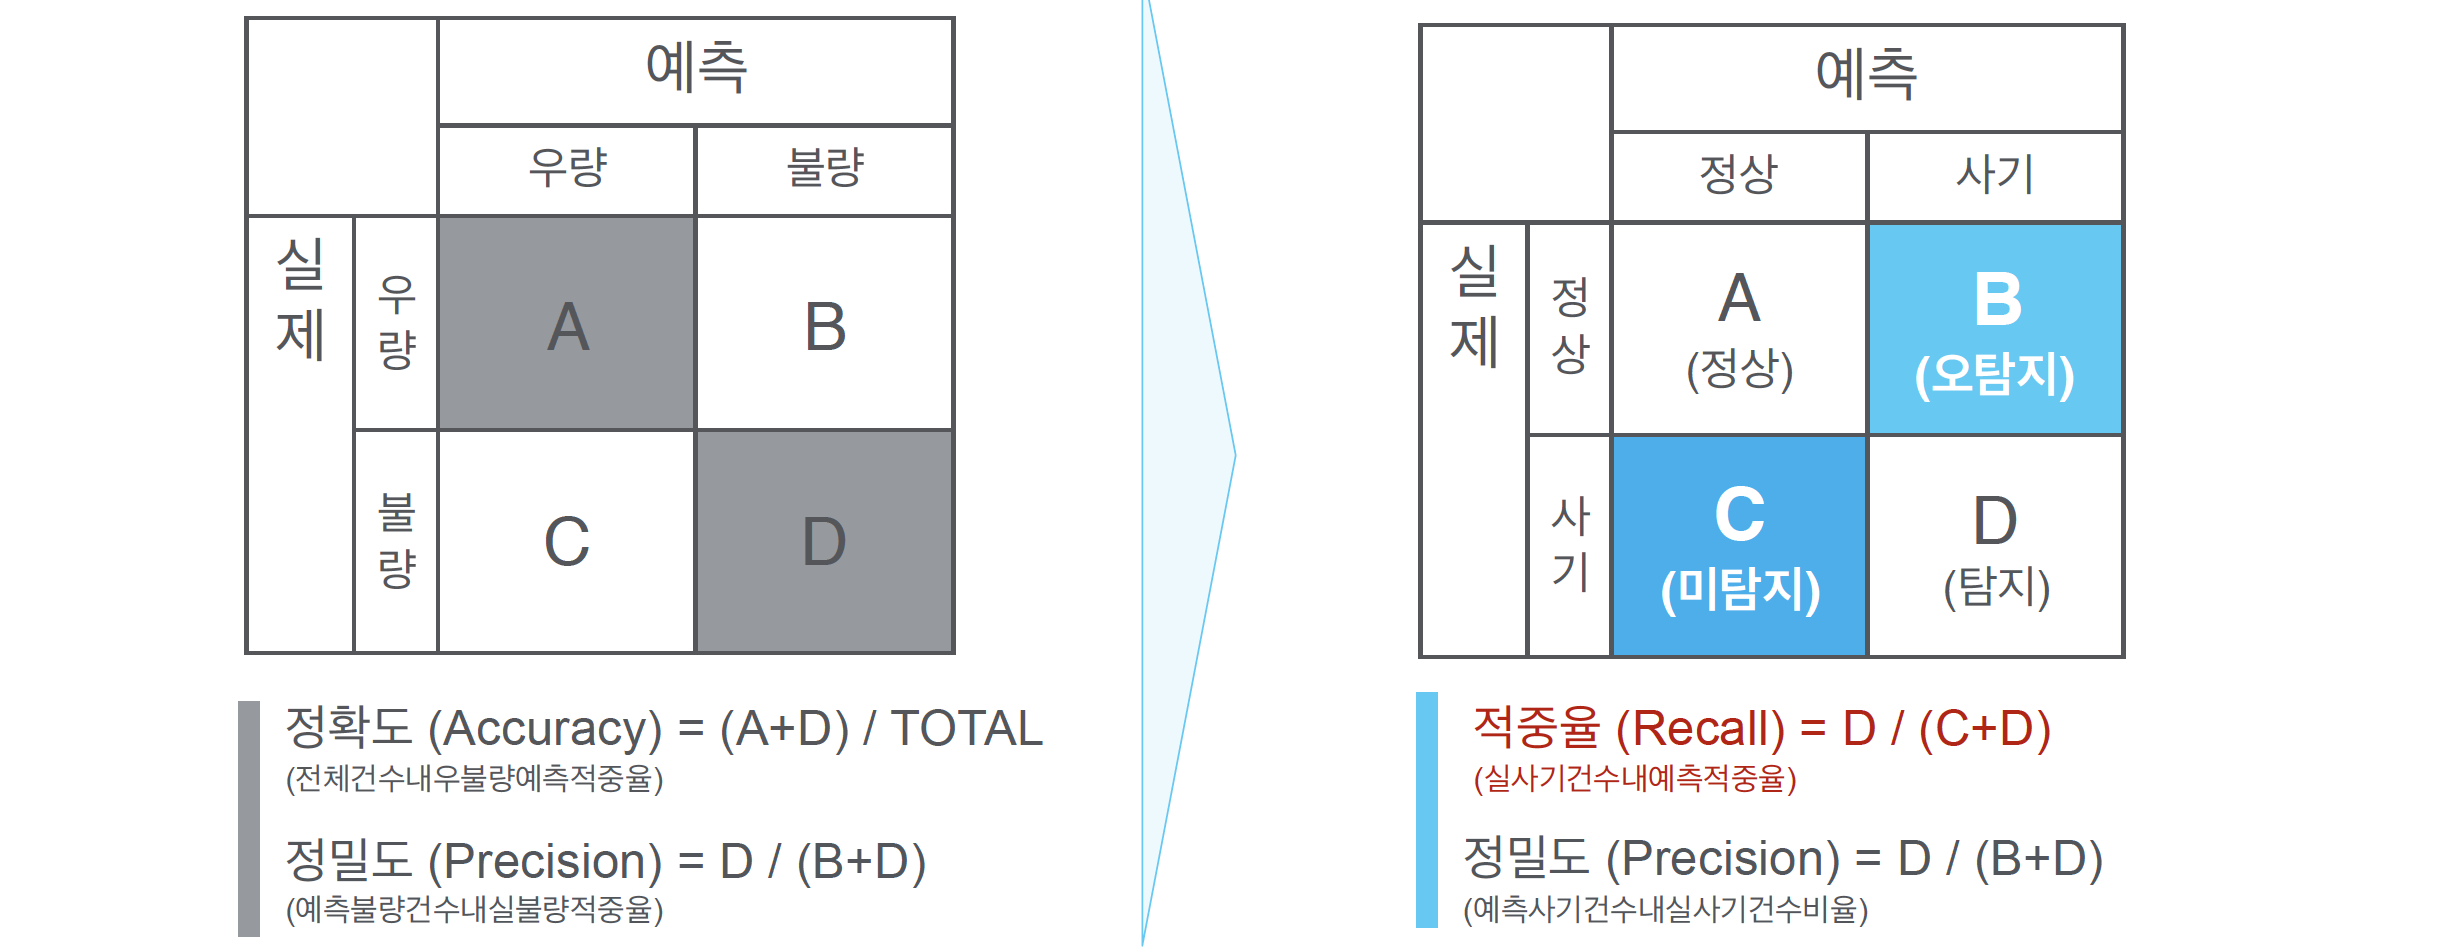